# Task 6: Loss Functions in Neural Network

This notebook turns the June 30 PDF into a runnable PyTorch notebook. The PDF title inside the document says Task 7, but the repo file is stored as Task 6, so this notebook follows the repo naming.

The main ideas are binary classification, sigmoid outputs, binary cross-entropy, and why `BCEWithLogitsLoss` is usually the best PyTorch choice.

## 1. Imports and reproducibility

We use NumPy for the from-scratch formulas, Matplotlib for plots, and PyTorch for the neural network examples.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Using device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

PyTorch version: 2.11.0+cu128
Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Binary classification recap

For binary classification, the target is usually `0` or `1`. A network can output a single score and convert it into a probability with a sigmoid function.

That probability then gets compared with the true label using binary cross-entropy.

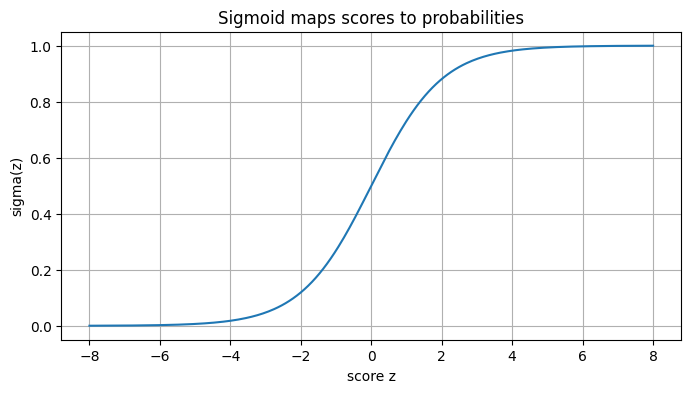

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

z = np.linspace(-8, 8, 300)
p = sigmoid(z)

plt.plot(z, p)
plt.title('Sigmoid maps scores to probabilities')
plt.xlabel('score z')
plt.ylabel('sigma(z)')
plt.show()

## 3. BCE from scratch with NumPy

This follows the formula from the PDF. We clip the probabilities slightly so we do not take `log(0)`.

In [ ]:
def bce_loss(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    loss = -(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))
    return float(np.mean(loss))

y_true_good = np.array([1, 0, 1, 0])
y_pred_good = np.array([0.99, 0.01, 0.95, 0.05])
y_true_bad = np.array([1, 0, 1, 0])
y_pred_bad = np.array([0.01, 0.99, 0.05, 0.95])

# Punishes you if you are confidently wrong
print('Loss for good predictions:', round(bce_loss(y_true_good, y_pred_good), 4))
print('Loss for bad predictions:', round(bce_loss(y_true_bad, y_pred_bad), 4))

Loss for good predictions: 0.0307
Loss for bad predictions: 3.8005


## 4. BCE intuition for both classes

These curves show why BCE strongly punishes confident wrong predictions.

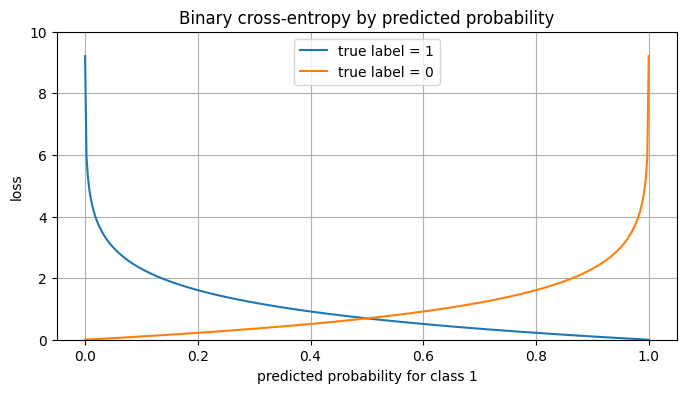

In [ ]:
probs = np.linspace(1e-4, 1 - 1e-4, 400)
loss_if_true_1 = -np.log(probs)
loss_if_true_0 = -np.log(1.0 - probs)

plt.plot(probs, loss_if_true_1, label='true label = 1')
plt.plot(probs, loss_if_true_0, label='true label = 0')
plt.title('Binary cross-entropy by predicted probability')
plt.xlabel('predicted probability for class 1')
plt.ylabel('loss')
plt.legend()
plt.ylim(0, 10)
plt.show()

#Orange represents as the true answer is 0 probability should go towards 0
#Blue represents as the true answer is 1 probability should go towards 1
#By showing they are opposites we see this works as a loss function

## 5. BCE vs MSE for binary probabilities

The PDF compares BCE and MSE conceptually. This plot makes that comparison visible for the case where the true label is `1`.

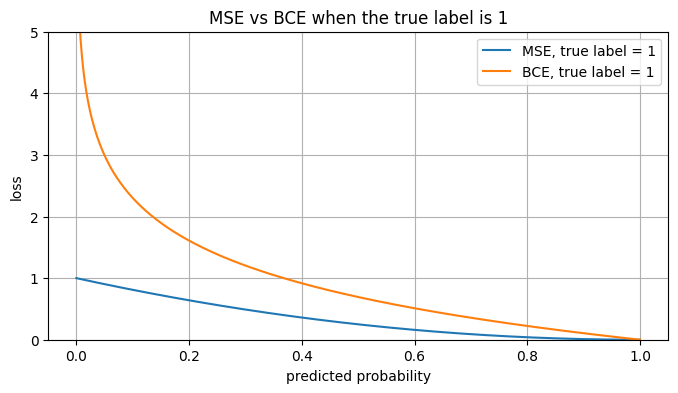

MSE at y_hat = 0.01: 0.9801
BCE at y_hat = 0.01: 4.6052


In [ ]:
mse_if_true_1 = (1.0 - probs) ** 2
bce_if_true_1 = -np.log(probs)

plt.plot(probs, mse_if_true_1, label='MSE, true label = 1')
plt.plot(probs, bce_if_true_1, label='BCE, true label = 1')
plt.title('MSE vs BCE when the true label is 1')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend()
plt.ylim(0, 5)
plt.show()

print('MSE at y_hat = 0.01:', round(float((1.0 - 0.01) ** 2), 4))
print('BCE at y_hat = 0.01:', round(float(-math.log(0.01)), 4))

# This shows BCE punishes bad predictions a lot harsher, compared to MSE

## 6. PyTorch BCE examples

PyTorch provides two common choices:
- `nn.BCELoss()` if you already have probabilities
- `nn.BCEWithLogitsLoss()` if your model outputs raw logits

The logits version is usually preferred because it is more numerically stable.

In [ ]:
scores = torch.tensor([[2.5], [-1.2], [3.1], [-0.5]], dtype=torch.float32, device=device)
targets = torch.tensor([[1.0], [0.0], [1.0], [0.0]], dtype=torch.float32, device=device)

loss_logits = nn.BCEWithLogitsLoss()(scores, targets)
probs_torch = torch.sigmoid(scores)
loss_probs = nn.BCELoss()(probs_torch, targets)

print('PyTorch BCEWithLogitsLoss:', round(loss_logits.item(), 4))
print('PyTorch BCELoss from probabilities:', round(loss_probs.item(), 4))

#Shows the function we made and the built in function for py torch behaves the same

PyTorch BCEWithLogitsLoss: 0.2151
PyTorch BCELoss from probabilities: 0.2151


## 7. Build a simple binary classification dataset

We create a small synthetic dataset so the loss function can be tested end to end with a real training loop.

Train shape: (960, 2) (960, 1)
Validation shape: (240, 2) (240, 1)


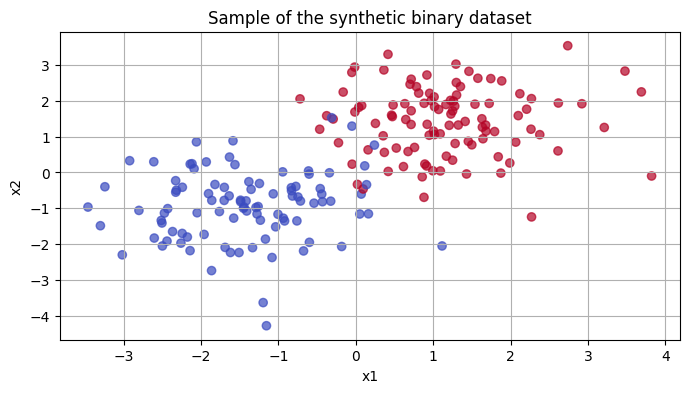

In [ ]:
def make_binary_dataset(num_samples=1200, seed=42):
    rng = np.random.default_rng(seed)
    x0 = rng.normal(loc=[-1.5, -1.0], scale=[0.9, 0.9], size=(num_samples // 2, 2))
    x1 = rng.normal(loc=[1.2, 1.5], scale=[0.9, 0.9], size=(num_samples // 2, 2))
    X = np.vstack([x0, x1]).astype(np.float32)
    y = np.concatenate([np.zeros(num_samples // 2), np.ones(num_samples // 2)]).astype(np.float32)

    order = rng.permutation(num_samples)
    X = X[order]
    y = y[order]
    return X, y

X, y = make_binary_dataset()
split = int(0.8 * len(X))
X_train = torch.tensor(X[:split], dtype=torch.float32)
y_train = torch.tensor(y[:split].reshape(-1, 1), dtype=torch.float32)
X_val = torch.tensor(X[split:], dtype=torch.float32)
y_val = torch.tensor(y[split:].reshape(-1, 1), dtype=torch.float32)

print('Train shape:', tuple(X_train.shape), tuple(y_train.shape))
print('Validation shape:', tuple(X_val.shape), tuple(y_val.shape))

plt.scatter(X[:200, 0], X[:200, 1], c=y[:200], cmap='coolwarm', alpha=0.7)
plt.title('Sample of the synthetic binary dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Blue is class zero meaning the answer is 0, Red is class one meaning the answer is one (binary classification)
# Model learns to look at x1 and x2 and predict which class it belongs to

## 8. Define the MLP

This is a small feedforward MLP. The final layer returns raw logits, not probabilities.

In [ ]:
class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

model = BinaryMLP().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

print(model)

# 3 linear layers, 2 reLU layers

BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 9. Train the network

This is the practical version of the conceptual training loop from the PDF: zero gradients, forward pass, compute BCE loss, backpropagate, and update the weights.

In [9]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True,
)

X_val_device = X_val.to(device)
y_val_device = y_val.to(device)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
num_epochs = 40

for epoch in range(num_epochs):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_device)
        val_loss = criterion(val_logits, y_val_device).item()
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs >= 0.5).float()
        val_acc = (val_preds.eq(y_val_device).float().mean().item())

    history['train_loss'].append(float(np.mean(batch_losses)))
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

print('Final train loss:', round(history['train_loss'][-1], 4))
print('Final val loss:', round(history['val_loss'][-1], 4))
print('Final val accuracy:', round(history['val_acc'][-1], 4))

Final train loss: 0.0563
Final val loss: 0.1257
Final val accuracy: 0.975


## 10. Plot training results

The loss should fall as training improves, while validation accuracy should rise if the classifier is learning the decision boundary well.

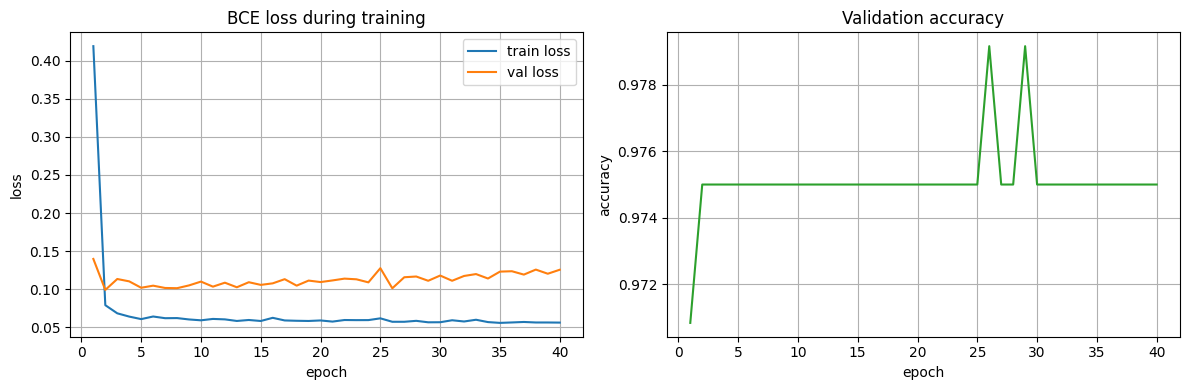

In [ ]:
epochs = np.arange(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], label='train loss')
axes[0].plot(epochs, history['val_loss'], label='val loss')
axes[0].set_title('BCE loss during training')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].plot(epochs, history['val_acc'], color='tab:green')
axes[1].set_title('Validation accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')

fig.tight_layout()
plt.show()

# Model learned pattern quick validation loss stabilizes between 0.10 to 0.12
# After that mostly satopped improving on new data
# Small gap between train and validation loss means mild overfitting 


## 11. Visualize the learned probabilities

This plot shows the final classifier probabilities over the 2D input space.

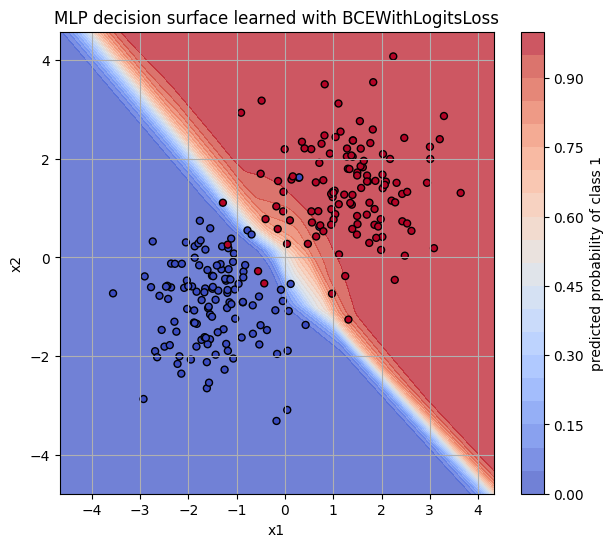

: 

In [ ]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()]).astype(np.float32)

model.eval()
with torch.no_grad():
    grid_logits = model(torch.tensor(grid, dtype=torch.float32, device=device))
    grid_probs = torch.sigmoid(grid_logits).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, grid_probs, levels=20, cmap='coolwarm', alpha=0.75)
plt.colorbar(label='predicted probability of class 1')
plt.scatter(X_val[:, 0].numpy(), X_val[:, 1].numpy(), c=y_val[:, 0].numpy(), cmap='coolwarm', edgecolor='k', s=25)
plt.title('MLP decision surface learned with BCEWithLogitsLoss')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Blue is class 0, red is class 1 , white is uncertain probalility around 0.5
# This shows MLP learned to seperate the clusters pretty well and the boundary is smooth not a hard line
# This shows the network is using the learned non-linear layers to classify the points

## 12. Main takeaway

This task shows three linked ideas:
- sigmoid turns raw scores into probabilities
- BCE measures how wrong those probabilities are
- `BCEWithLogitsLoss` is the preferred PyTorch implementation because it is stable and simple

For binary classification, that combination is usually a much better default than MSE.